In [1]:
import pandas as pd
import seaborn as sns

In [3]:
df=pd.read_csv("/Users/bhijanbastola/Desktop/intern/Data/Iris.csv")

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
df.shape

(150, 6)

Our dataset has 150 rows and 6 cloumns

In [13]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

This schema output confirms the dataset structure, consisting of five feature columns alongside a dataset index. The four morphological dimensions—SepalLengthCm, SepalWidthCm, PetalLengthCm, and PetalWidthCm—are stored as 64-bit floating-point numbers (float64), providing continuous numerical values essential for model training. The target variable, Species, is represented as a text string (object), which will require label encoding or mapping to numeric classes prior to model execution. Lastly, the Id column is listed as a 64-bit integer (int64); because it functions purely as a sample index—and has been shown to introduce spurious target leakage due to sequential ordering—it must be dropped from the feature set before running machine learning algorithms.

In [12]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


This summary table presents the descriptive statistics (`df.describe()`) for the numerical features of the Iris dataset across 150 total observations. The dataset exhibits no missing values across any columns (all counts equal 150). **`PetalLengthCm`** displays the largest variance and spread, spanning from 1.00 cm to 6.90 cm with a mean of 3.76 cm ($\text{std} = 1.76$), reflecting the clear separation between shorter-petaled *setosa* and longer-petaled *virginica* species observed in previous plots. Similarly, **`PetalWidthCm`** shows significant dispersion around a mean of 1.20 cm ($\text{std} = 0.76$, range 0.10 to 2.50 cm). By contrast, **`SepalWidthCm`** is the most tightly clustered feature with a low standard deviation ($\text{std} = 0.43$) around its mean of 3.05 cm. **`SepalLengthCm`** ranges from 4.30 cm to 7.90 cm, with its median (5.80 cm) closely matching its mean (5.84 cm), indicating a fairly symmetrical overall distribution. Finally, the **`Id`** statistics simply confirm a uniform index range from 1 to 150, reinforcing that it should be removed before feature processing.

In [14]:
df.isna().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

There are no null values in our data set.

In [15]:
df.Species.value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

We have equal number of data for each flower data set (i.e. 50).


In [23]:
filtered_df = df[df["SepalLengthCm"] > 5.0]

In [24]:
filterd_df.head()

,SepalLengthCm
0,True
1,False
2,False
3,False
4,False


In [28]:
filtered_df=filtered_df.sort_values(by="SepalLengthCm",ascending=False)

In [29]:
filtered_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
131,132,7.9,3.8,6.4,2.0,Iris-virginica
122,123,7.7,2.8,6.7,2.0,Iris-virginica
118,119,7.7,2.6,6.9,2.3,Iris-virginica
117,118,7.7,3.8,6.7,2.2,Iris-virginica
135,136,7.7,3.0,6.1,2.3,Iris-virginica
...,...,...,...,...,...,...
23,24,5.1,3.3,1.7,0.5,Iris-setosa
39,40,5.1,3.4,1.5,0.2,Iris-setosa
44,45,5.1,3.8,1.9,0.4,Iris-setosa
46,47,5.1,3.8,1.6,0.2,Iris-setosa


In [32]:
filtered_df["sepal_petal_ratio"] = filtered_df["SepalLengthCm"] / filtered_df["PetalWidthCm"]

In [33]:
filtered_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,sepal_petal_ratio
131,132,7.9,3.8,6.4,2.0,Iris-virginica,3.950000
122,123,7.7,2.8,6.7,2.0,Iris-virginica,3.850000
118,119,7.7,2.6,6.9,2.3,Iris-virginica,3.347826
117,118,7.7,3.8,6.7,2.2,Iris-virginica,3.500000
135,136,7.7,3.0,6.1,2.3,Iris-virginica,3.347826
...,...,...,...,...,...,...,...
23,24,5.1,3.3,1.7,0.5,Iris-setosa,10.200000
39,40,5.1,3.4,1.5,0.2,Iris-setosa,25.500000
44,45,5.1,3.8,1.9,0.4,Iris-setosa,12.750000
46,47,5.1,3.8,1.6,0.2,Iris-setosa,25.500000


<Axes: xlabel='SepalLengthCm', ylabel='Count'>

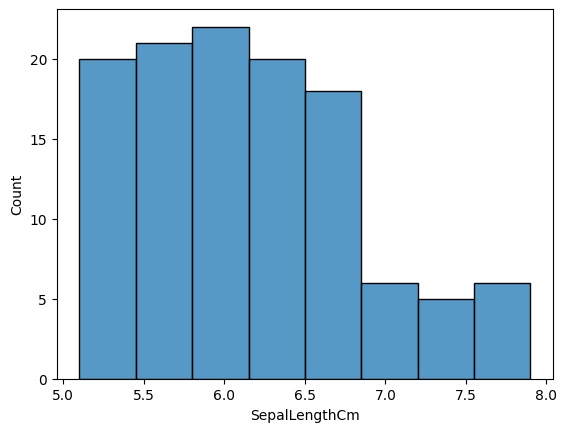

In [34]:
sns.histplot(filtered_df,x="SepalLengthCm")

This histogram illustrates the distribution of the continuous feature **`SepalLengthCm`** across a range of approximately 5.1 cm to 7.9 cm. The feature exhibits a moderately right-skewed, unimodal distribution, where the bulk of the data points fall within the 5.1 cm to 6.8 cm range and peak around 5.8–6.2 cm (with a maximum count of 22). Frequency drops off sharply beyond 6.8 cm into a sparse upper tail, indicating that while the values remain bounded within a normal biological scale without severe outliers, most observations cluster tightly in the lower-to-mid range.

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

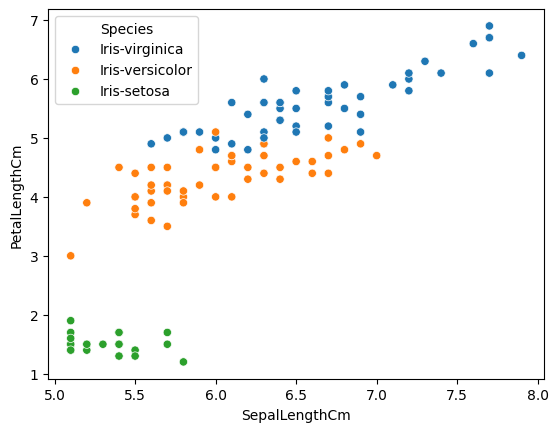

In [36]:
sns.scatterplot(filtered_df,x="SepalLengthCm",y="PetalLengthCm",hue="Species")

Bivariate Analysis: SepalLengthCm vs. PetalLengthCm
The scatter plot demonstrates strong feature interaction and class separability. Iris-setosa forms a distinct, low-value cluster along the petal length axis (≤2.0 cm). Iris-versicolor and Iris-virginica show a strong positive linear relationship between sepal and petal lengths. Because PetalLengthCm clearly delineates setosa and provides strong separation between versicolor and virginica, it serves as a highly informative feature for classification models.

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

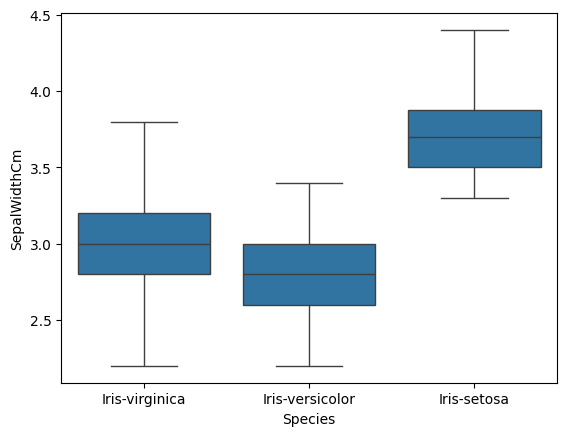

In [39]:
sns.boxplot(filtered_df,y="SepalWidthCm",x="Species")

Categorical Bivariate Analysis: Species vs. SepalWidthCm
The box plot highlights significant variance in sepal width across species categories. Iris-setosa possesses the widest sepals overall (median ~3.7 cm, range 3.3–4.4 cm), rendering SepalWidthCm a strong individual feature for isolating setosa. In contrast, Iris-versicolor and Iris-virginica exhibit substantial overlap in their interquartile ranges (medians of ~2.8 cm and ~3.0 cm), indicating that sepal width must be combined with additional features (such as petal length or width) for linear or tree-based classifiers to separate these two classes effectively.

<Axes: >

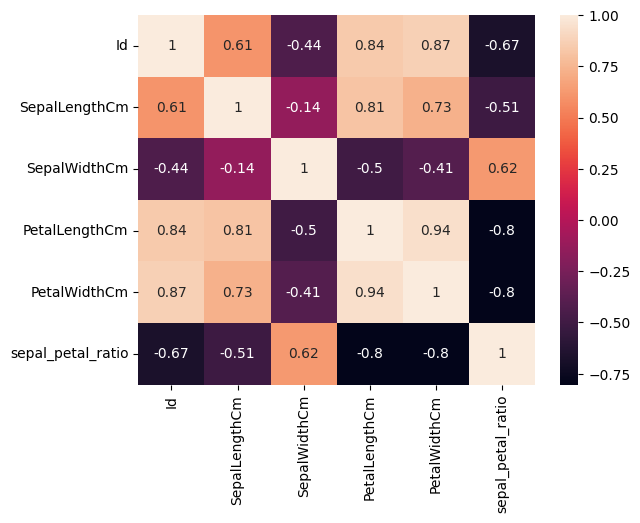

In [41]:
sns.heatmap(filtered_df.corr(numeric_only=True),annot=True)

Multivariate Analysis: Feature Correlation Matrix
The heatmap highlights strong linear dependencies across physical features. The high correlation between PetalLengthCm and PetalWidthCm (r=0.94) points to potential redundancy; tree-based algorithms will handle this naturally, but linear models may benefit from dimensionality reduction (e.g., PCA) or feature selection. Additionally, the non-trivial correlation between Id and morphological features confirms sequential species ordering in the raw file. Id must be dropped prior to model training to prevent target leakage and spurious feature reliance.